# Houston Housing Market Analytics: Descriptive Analysis

This notebook performs descriptive and trend analysis on `data/houston_housing_market.csv`,
a monthly Houston-metro housing dataset built from Redfin, FRED (Freddie Mac), City of
Houston Open Data, and Zillow Research. See `README.md`, `data/source_notes.md`, and
`methodology/README.md` for full source and methodology documentation.

This is descriptive and trend analysis intended for business intelligence and decision
support context. It does not make causal claims about what drives housing market changes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

FIG_DIR = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)

COLOR_PRIMARY = "#1f4e79"
COLOR_SECONDARY = "#c0693f"
COLOR_ACCENT = "#4c9a76"
COLOR_MUTED = "#8c8c8c"


## 1. Load the dataset

In [2]:
df = pd.read_csv("../data/houston_housing_market.csv", parse_dates=["month"])
df = df.sort_values("month").reset_index(drop=True)
df.shape

(173, 22)

## 2. Validate shape, missing values, dates, and column types

In [3]:
print("Rows, columns:", df.shape)
print("Date range:", df["month"].min().date(), "to", df["month"].max().date())
print()
print(df.dtypes)

Rows, columns: (173, 22)
Date range: 2012-01-01 to 2026-05-01

month                           datetime64[ns]
market_area                             object
closed_sales                           float64
pending_sales                          float64
active_listings                        float64
new_listings                           float64
months_inventory                       float64
median_price                           float64
days_on_market                         float64
sale_to_list_ratio                     float64
single_family_permits                  float64
multi_family_permits                   float64
mortgage_rate_30yr                     float64
zhvi_typical_home_value                float64
price_yoy_change                       float64
sales_yoy_change                       float64
inventory_yoy_change                   float64
dom_yoy_change                         float64
permit_yoy_change                      float64
affordability_pressure_index           float

In [4]:
missing = df.isna().sum()
missing[missing > 0]

single_family_permits    5
multi_family_permits     5
permit_yoy_change        5
dtype: int64

In [5]:
# Confirm one row per month (no duplicate months) and a continuous monthly index
assert df["month"].is_unique, "Duplicate months found"
full_range = pd.date_range(df["month"].min(), df["month"].max(), freq="MS")
gaps = set(full_range) - set(df["month"])
print("Missing months in the sequence:", sorted(gaps))
print("Row count matches expected monthly sequence:", len(df) == len(full_range))

Missing months in the sequence: []
Row count matches expected monthly sequence: True


## 3. Dataset and source coverage summary

Quick reference before the analysis: which columns come from which source, and where each
source's coverage starts/ends within this dataset.

In [6]:
coverage = pd.DataFrame({
    "column": ["closed_sales/pending_sales/active_listings/new_listings/months_inventory/"
               "median_price/days_on_market/sale_to_list_ratio/*_yoy_change (price,sales,inv,dom)",
               "mortgage_rate_30yr",
               "single_family_permits/multi_family_permits/permit_yoy_change",
               "zhvi_typical_home_value"],
    "source": ["Redfin Data Center (metro, non-seasonally-adjusted)",
               "FRED MORTGAGE30US (Freddie Mac), weekly avg'd to monthly",
               "City of Houston Open Data, residential permits",
               "Zillow Research ZHVI, Houston metro"],
    "geography": ["Houston, TX metro area", "National", "City of Houston jurisdiction", "Houston, TX metro area"],
    "first_non_null_month": [
        df.loc[df["median_price"].notna(), "month"].min().date(),
        df.loc[df["mortgage_rate_30yr"].notna(), "month"].min().date(),
        df.loc[df["single_family_permits"].notna(), "month"].min().date(),
        df.loc[df["zhvi_typical_home_value"].notna(), "month"].min().date(),
    ],
    "last_non_null_month": [
        df.loc[df["median_price"].notna(), "month"].max().date(),
        df.loc[df["mortgage_rate_30yr"].notna(), "month"].max().date(),
        df.loc[df["single_family_permits"].notna(), "month"].max().date(),
        df.loc[df["zhvi_typical_home_value"].notna(), "month"].max().date(),
    ],
})
coverage

,column,source,geography,first_non_null_month,last_non_null_month
0,closed_sales/pending_sales/active_listings/new...,"Redfin Data Center (metro, non-seasonally-adju...","Houston, TX metro area",2012-01-01,2026-05-01
1,mortgage_rate_30yr,"FRED MORTGAGE30US (Freddie Mac), weekly avg'd ...",National,2012-01-01,2026-05-01
2,single_family_permits/multi_family_permits/per...,"City of Houston Open Data, residential permits",City of Houston jurisdiction,2012-01-01,2025-12-01
3,zhvi_typical_home_value,"Zillow Research ZHVI, Houston metro","Houston, TX metro area",2012-01-01,2026-05-01


In [7]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
month,173,2019-03-02 07:54:27.052023040,2012-01-01 00:00:00,2015-08-01 00:00:00,2019-03-01 00:00:00,2022-10-01 00:00:00,2026-05-01 00:00:00,NaN
closed_sales,173.0,7272.034682,3291.0,6299.0,7251.0,8304.0,11111.0,1534.105428
pending_sales,173.0,8860.82659,3291.0,7546.0,8919.0,10182.0,12911.0,1830.944582
active_listings,173.0,24458.809249,12567.0,20459.0,23651.0,28418.0,39355.0,5869.982249
new_listings,173.0,9335.213873,4424.0,7892.0,9288.0,10808.0,13832.0,2039.491645
months_inventory,173.0,3.552601,1.3,2.8,3.4,4.2,9.3,1.221397
median_price,173.0,256567.291908,138250.0,209250.0,241000.0,325800.0,351500.0,60941.301072
days_on_market,173.0,44.722543,10.0,31.0,40.0,53.0,125.0,22.019373
sale_to_list_ratio,173.0,0.974812,0.9565,0.9696,0.9731,0.9774,1.0098,0.009572
single_family_permits,168.0,458.988095,199.0,388.75,450.0,535.25,775.0,108.659055


## 4. Sales and pending sales trend

Closed sales and pending sales are the two most direct measures of transaction activity.
Pending sales typically lead closed sales by roughly a month.

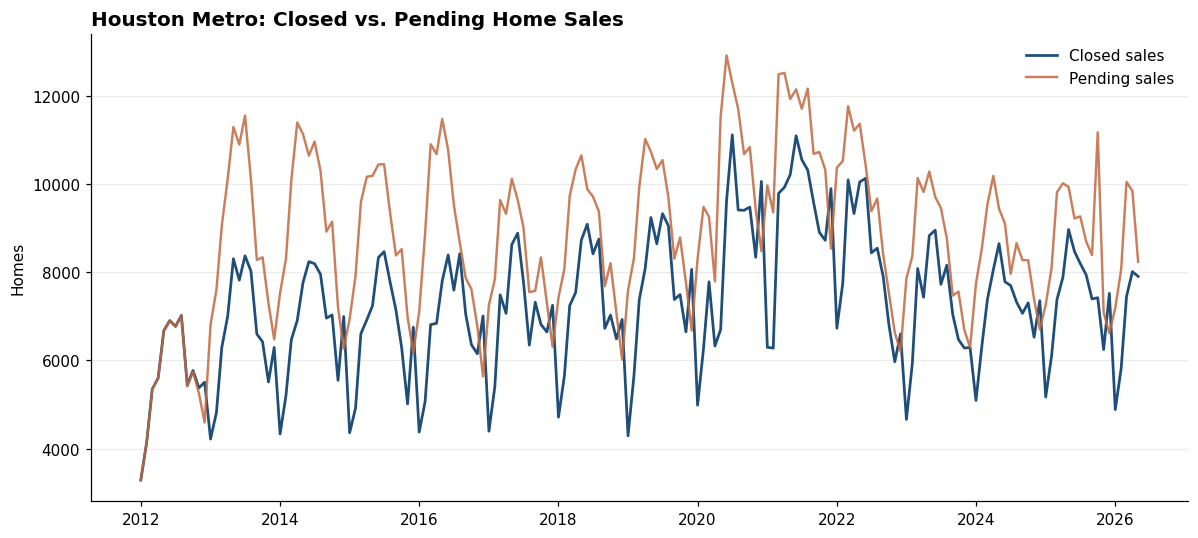

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(df["month"], df["closed_sales"], color=COLOR_PRIMARY, linewidth=1.8, label="Closed sales")
ax.plot(df["month"], df["pending_sales"], color=COLOR_SECONDARY, linewidth=1.6, label="Pending sales", alpha=0.85)
ax.set_title("Houston Metro: Closed vs. Pending Home Sales", fontsize=13, fontweight="bold", loc="left")
ax.set_ylabel("Homes")
ax.set_xlabel("")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "01_sales_pending_sales_trend.png", dpi=150)
plt.show()

## 5. Median price and Zillow ZHVI trend

Redfin's median sale price (transaction-based) and Zillow's ZHVI (a smoothed typical
home value index) are methodologically different but broadly comparable price signals.

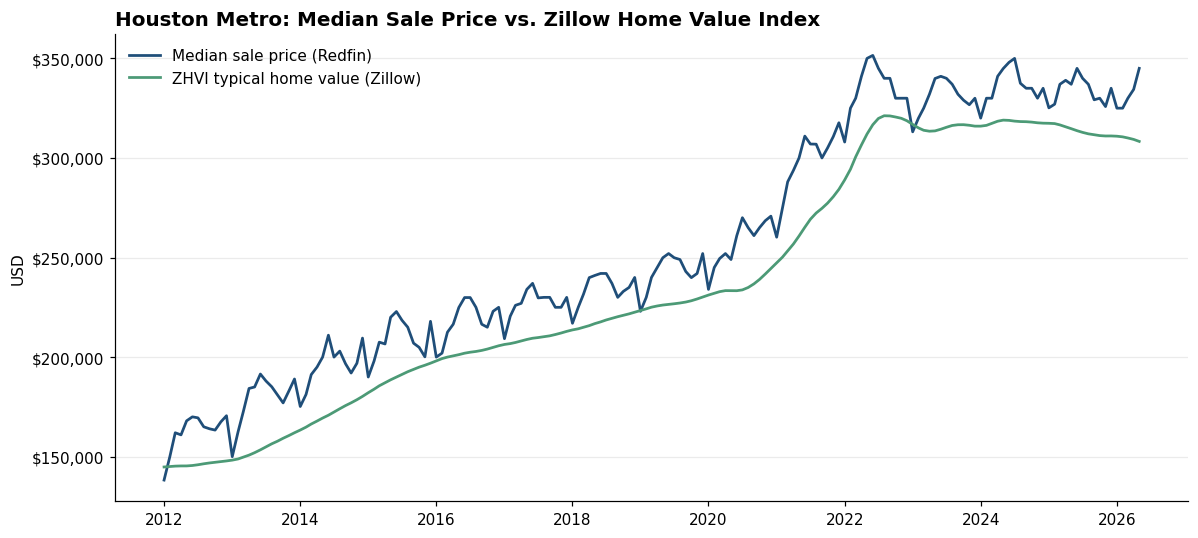

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(df["month"], df["median_price"], color=COLOR_PRIMARY, linewidth=1.8, label="Median sale price (Redfin)")
ax.plot(df["month"], df["zhvi_typical_home_value"], color=COLOR_ACCENT, linewidth=1.8, label="ZHVI typical home value (Zillow)")
ax.set_title("Houston Metro: Median Sale Price vs. Zillow Home Value Index", fontsize=13, fontweight="bold", loc="left")
ax.set_ylabel("USD")
ax.yaxis.set_major_formatter(lambda x, pos: f"${x:,.0f}")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_price_zhvi_trend.png", dpi=150)
plt.show()

## 6. Inventory, months of supply, and days on market

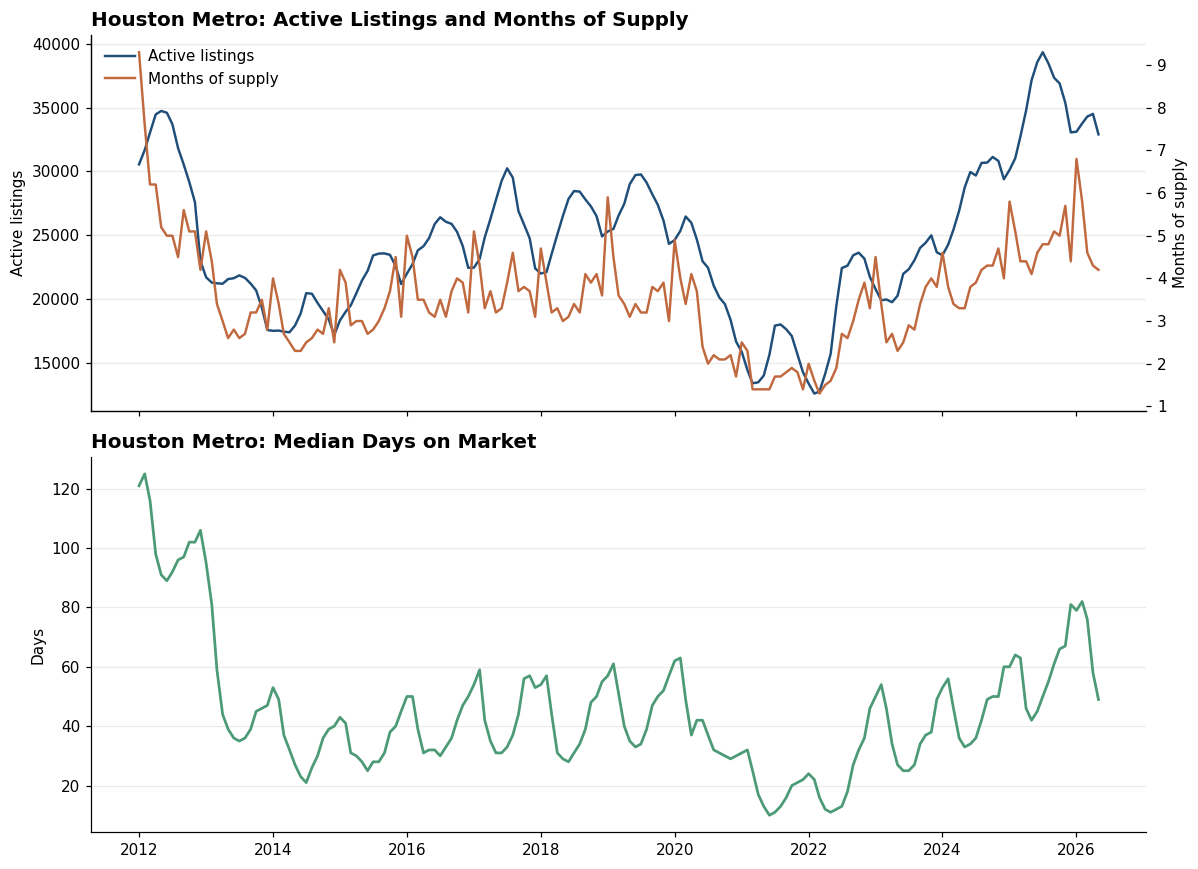

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

ax1.plot(df["month"], df["active_listings"], color=COLOR_PRIMARY, linewidth=1.6, label="Active listings")
ax1b = ax1.twinx()
ax1b.plot(df["month"], df["months_inventory"], color=COLOR_SECONDARY, linewidth=1.6, label="Months of supply")
ax1.set_title("Houston Metro: Active Listings and Months of Supply", fontsize=13, fontweight="bold", loc="left")
ax1.set_ylabel("Active listings")
ax1b.set_ylabel("Months of supply")
lines1, labels1 = ax1.get_legend_handles_labels()
lines1b, labels1b = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines1b, labels1 + labels1b, frameon=False, loc="upper left")
ax1.grid(axis="y", alpha=0.25)

ax2.plot(df["month"], df["days_on_market"], color=COLOR_ACCENT, linewidth=1.8)
ax2.set_title("Houston Metro: Median Days on Market", fontsize=13, fontweight="bold", loc="left")
ax2.set_ylabel("Days")
ax2.grid(axis="y", alpha=0.25)

fig.tight_layout()
fig.savefig(FIG_DIR / "03_inventory_months_supply_trend.png", dpi=150)
plt.show()

## 7. Days on market trend (standalone view)

A dedicated view of the days-on-market series, since it's one of the clearest
buyer-vs-seller leverage signals in the dataset.

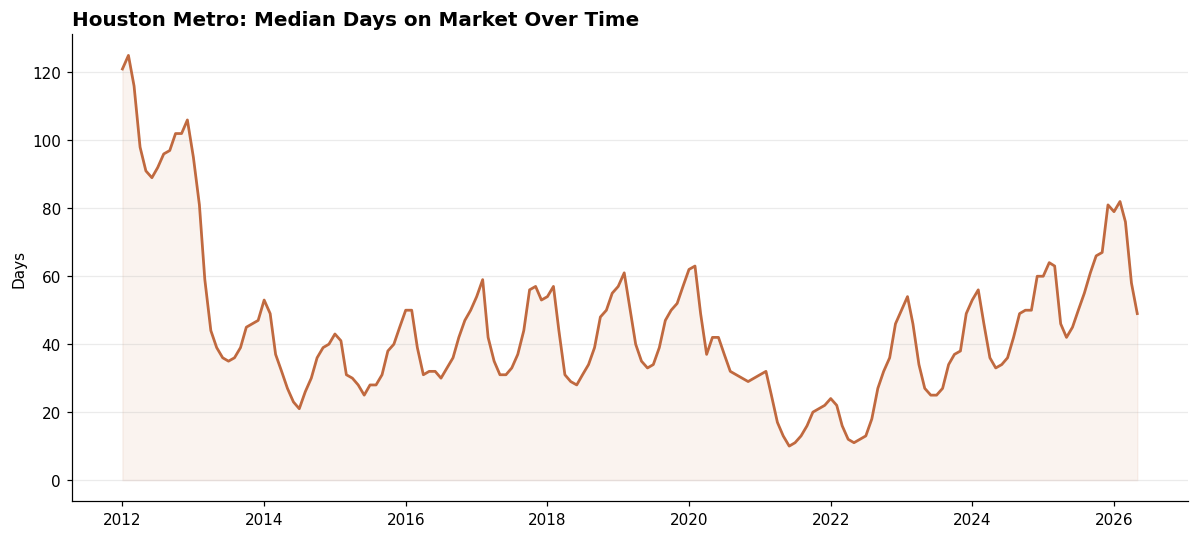

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(df["month"], df["days_on_market"], color=COLOR_SECONDARY, linewidth=1.8)
ax.fill_between(df["month"], df["days_on_market"], alpha=0.08, color=COLOR_SECONDARY)
ax.set_title("Houston Metro: Median Days on Market Over Time", fontsize=13, fontweight="bold", loc="left")
ax.set_ylabel("Days")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "04_days_on_market_trend.png", dpi=150)
plt.show()

## 8. Mortgage-rate context

The 30-year mortgage rate is a national series (not Houston-specific) included as
macroeconomic context for financing conditions alongside local sales activity.

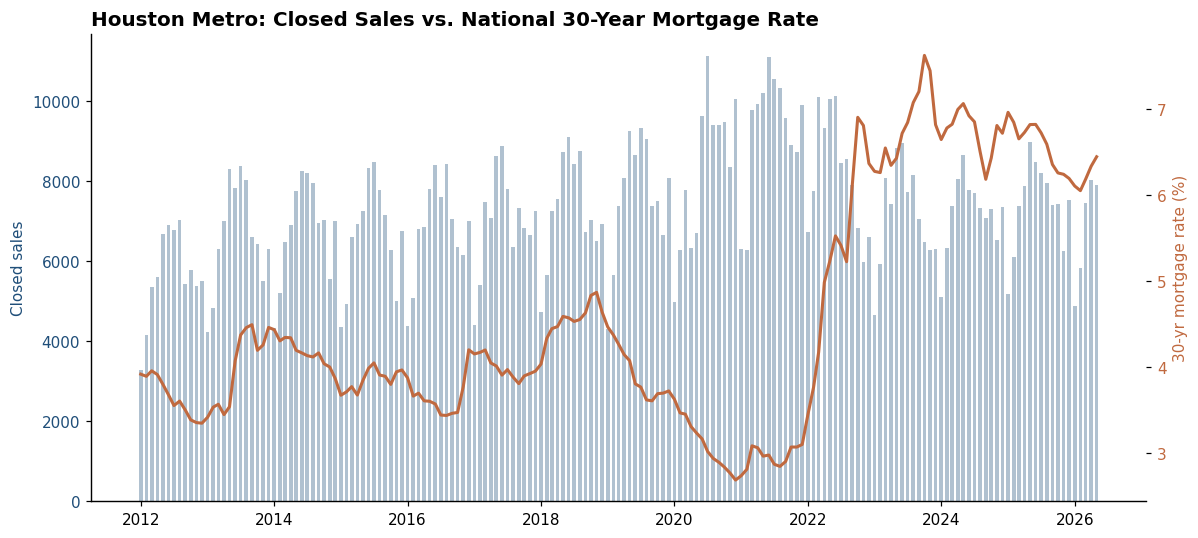

In [12]:
fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(df["month"], df["closed_sales"], width=20, color=COLOR_PRIMARY, alpha=0.35, label="Closed sales")
ax1.set_ylabel("Closed sales", color=COLOR_PRIMARY)
ax1.tick_params(axis="y", labelcolor=COLOR_PRIMARY)

ax2 = ax1.twinx()
ax2.plot(df["month"], df["mortgage_rate_30yr"], color=COLOR_SECONDARY, linewidth=2.0, label="30-yr mortgage rate")
ax2.set_ylabel("30-yr mortgage rate (%)", color=COLOR_SECONDARY)
ax2.tick_params(axis="y", labelcolor=COLOR_SECONDARY)

ax1.set_title("Houston Metro: Closed Sales vs. National 30-Year Mortgage Rate", fontsize=13, fontweight="bold", loc="left")
fig.tight_layout()
fig.savefig(FIG_DIR / "05_mortgage_rate_vs_sales.png", dpi=150)
plt.show()

In [13]:
corr = df[["closed_sales", "pending_sales", "mortgage_rate_30yr"]].corr()
corr

,closed_sales,pending_sales,mortgage_rate_30yr
closed_sales,1.000000,0.728789,-0.086272
pending_sales,0.728789,1.000000,-0.163245
mortgage_rate_30yr,-0.086272,-0.163245,1.000000


## 9. Permits as supply-side context

City of Houston permit counts (city jurisdiction, narrower than the metro) offer a
directional read on new construction supply feeding into the broader market.

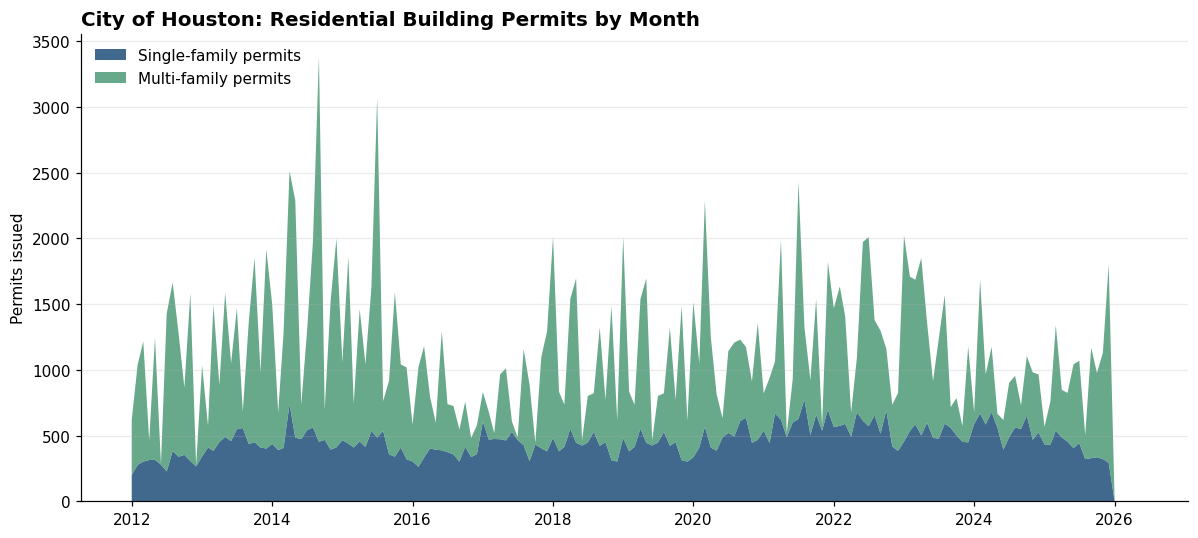

In [14]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.stackplot(
    df["month"],
    df["single_family_permits"].fillna(0),
    df["multi_family_permits"].fillna(0),
    labels=["Single-family permits", "Multi-family permits"],
    colors=[COLOR_PRIMARY, COLOR_ACCENT],
    alpha=0.85,
)
ax.set_title("City of Houston: Residential Building Permits by Month", fontsize=13, fontweight="bold", loc="left")
ax.set_ylabel("Permits issued")
ax.legend(frameon=False, loc="upper left")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "06_permits_supply_context.png", dpi=150)
plt.show()

## 10. Affordability pressure and market condition score

Both indicators are simple, transparent z-score composites computed relative to this
dataset's own history; see `methodology/README.md` for the exact formulas. They are
not official or industry-standard indices.

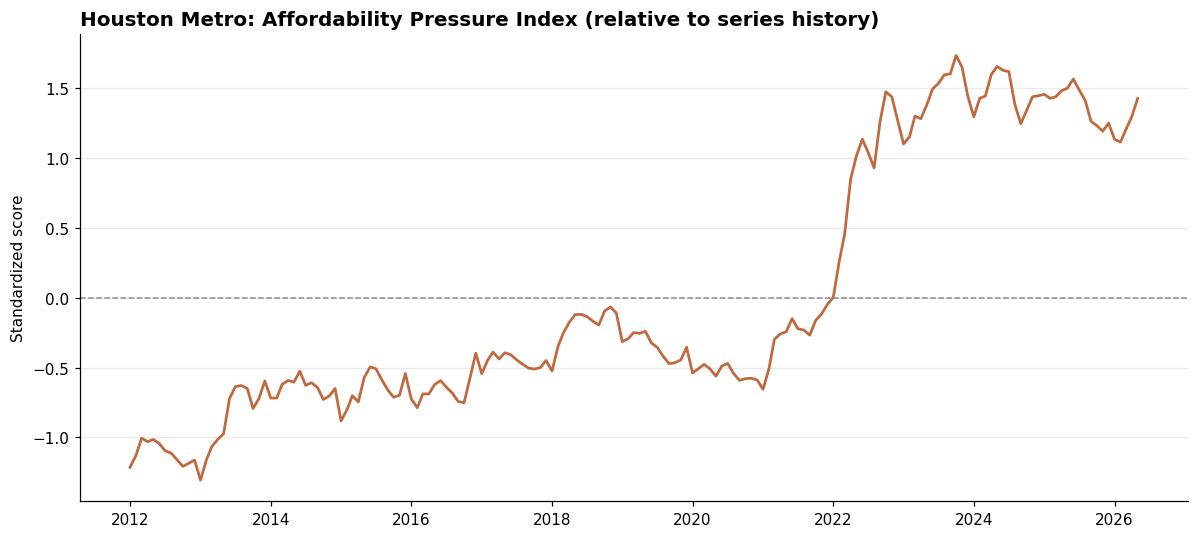

In [15]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(df["month"], df["affordability_pressure_index"], color=COLOR_SECONDARY, linewidth=1.8)
ax.axhline(0, color=COLOR_MUTED, linewidth=1, linestyle="--")
ax.set_title("Houston Metro: Affordability Pressure Index (relative to series history)", fontsize=13, fontweight="bold", loc="left")
ax.set_ylabel("Standardized score")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "07_affordability_pressure_index.png", dpi=150)
plt.show()

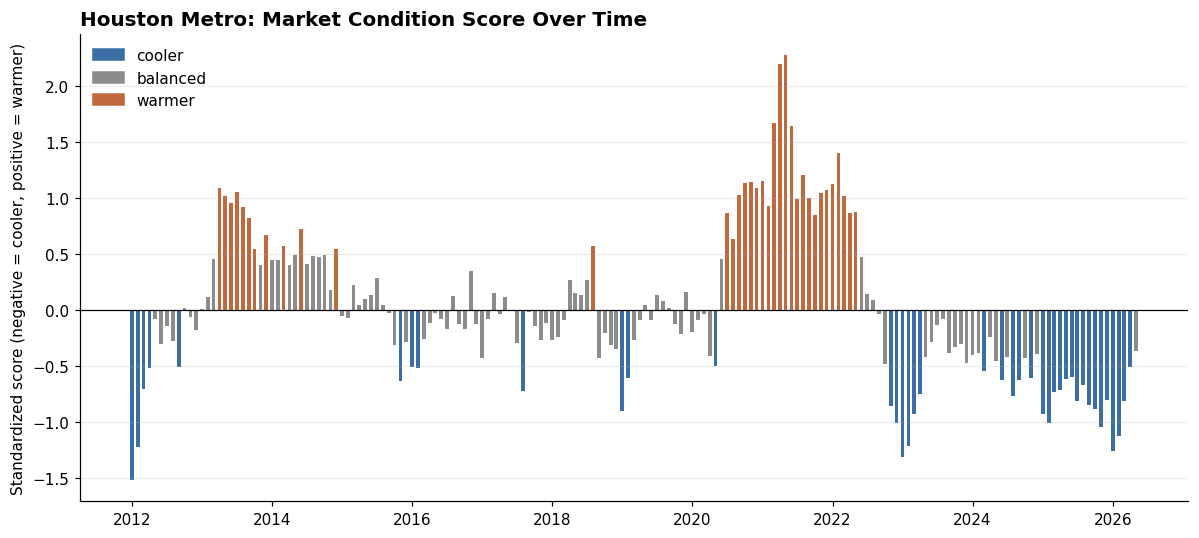

In [16]:
label_colors = {"cooler": "#3b6ea5", "balanced": "#8c8c8c", "warmer": "#c0693f"}
colors = df["market_condition_label"].map(label_colors)

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(df["month"], df["market_condition_score"], width=20, color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Houston Metro: Market Condition Score Over Time", fontsize=13, fontweight="bold", loc="left")
ax.set_ylabel("Standardized score (negative = cooler, positive = warmer)")
ax.grid(axis="y", alpha=0.25)

from matplotlib.patches import Patch
handles = [Patch(color=c, label=l) for l, c in label_colors.items()]
ax.legend(handles=handles, frameon=False, loc="upper left")

fig.tight_layout()
fig.savefig(FIG_DIR / "08_market_condition_score.png", dpi=150)
plt.show()

In [17]:
df["market_condition_label"].value_counts()

market_condition_label
balanced    99
cooler      39
warmer      35
Name: count, dtype: int64

In [18]:
df.groupby(df["month"].dt.year)["market_condition_label"].agg(lambda s: s.value_counts().idxmax()).to_frame("dominant_label_by_year")

,dominant_label_by_year
month,
2012,balanced
2013,warmer
2014,balanced
2015,balanced
2016,balanced
2017,balanced
2018,balanced
2019,balanced
2020,warmer


## 11. Findings summary

Sales activity: closed and pending sales show clear seasonal cycles (higher in
spring and summer) layered on top of longer multi-year swings tied to broader market
conditions.

Pricing: median sale price (Redfin) and ZHVI (Zillow) move together over the long
run, as expected given both track the same underlying metro market, though ZHVI's
smoothing means it lags and dampens month-to-month swings in the median price series.

Inventory and days on market: months of supply and days on market tend to move
together directionally. Tighter supply (fewer months of inventory) has historically
coincided with faster-selling homes (lower days on market), consistent with basic
supply-demand dynamics, though this dataset does not test that relationship causally.

Mortgage-rate context: the national 30-year mortgage rate provides useful macro
context alongside local sales activity. The correlation table above quantifies the
co-movement over this dataset's window without asserting a causal link.

Permits: City of Houston permit activity (city jurisdiction only) offers a
directional supply-side signal but should not be read as a metro-wide construction
count, given the geography mismatch documented in `data/source_notes.md`.

Composite indicators: the affordability pressure index and market condition score
are transparent, simple, and relative to this dataset's own history. They're useful
for spotting relatively warmer or cooler periods at a glance, not for benchmarking
against other markets or making forward-looking predictions.

See `case-study/houston_housing_market_analysis.md` for the full question-driven
write-up, and `methodology/README.md` for complete formula documentation and
limitations.